# Classifying satellite images to monitor Earth’s surface
### By Arian Bahram, Arianna Gonzalez, & Naina Talasu

This notebook walks through loading the dataset, exploring images, building PyTorch dataloaders, training a custom CNN and an improved variant, then comparing against ResNet50 (frozen head and a fine-tuned setup). Run cells top to bottom; training sections can take a long time on CPU.

**Sections:** (1) Data loading & exploration · (2) Splits & dataloaders · (3) Custom CNNs · (4) ResNet50 · (5) Fine-tuned ResNet & full comparison


In [1]:
import kagglehub
import pandas as pd
import os


# Download latest version
path = kagglehub.dataset_download("mahmoudreda55/satellite-image-classification")

print("Path to dataset files:", path)

data_dir = os.path.join(path, "data")
rows = []

for label in os.listdir(data_dir):
    class_path = os.path.join(data_dir, label)

    if os.path.isdir(class_path):
        for img in os.listdir(class_path):
            img_path = os.path.join(class_path, img)
            rows.append([img_path, label])

df = pd.DataFrame(rows, columns=["image_path", "label"])
df.to_csv("satellite_dataset.csv", index=False)

print(df.head())

Using Colab cache for faster access to the 'satellite-image-classification' dataset.
Path to dataset files: /kaggle/input/satellite-image-classification
                                          image_path   label
0  /kaggle/input/satellite-image-classification/d...  cloudy
1  /kaggle/input/satellite-image-classification/d...  cloudy
2  /kaggle/input/satellite-image-classification/d...  cloudy
3  /kaggle/input/satellite-image-classification/d...  cloudy
4  /kaggle/input/satellite-image-classification/d...  cloudy


## 1. Dataset exploration

Counts, class balance, sample thumbnails, typical resolutions, and raw pixel ranges.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Class counts
images = df.groupby("label")["image_path"].apply(list).to_dict()
image_count = df["label"].value_counts().to_dict()
print(image_count)
total_images = len(df)
print(f"Total images: {total_images}")

# Class distribution bar chart
counts = df["label"].value_counts()
plt.figure()
counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

# One random sample per class
plt.figure(figsize=(10, 6))
for i, label in enumerate(df["label"].unique()):
    sample = df[df["label"] == label].sample(1).iloc[0]
    img = Image.open(sample["image_path"])
    plt.subplot(1, 4, i + 1)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")
plt.tight_layout()
plt.show()

# Typical image sizes (sample for speed)
sizes = []
for path in df["image_path"][:200]:
    img = Image.open(path)
    sizes.append(img.size)
print(set(sizes))

# Pixel range on one image
img = Image.open(df.iloc[0]["image_path"])
img_array = np.array(img)
print("Shape:", img_array.shape)
print("Min pixel:", img_array.min())
print("Max pixel:", img_array.max())


## 2. Normalization preview

Compare min–max, z-score, and histogram equalization on sample images (the trained models use their own `transforms` later).

In [ ]:
import cv2


def normalize_image(image):
    # Min-max
    min_max = image / 255.0

    # Z-score
    z_score = (image - np.mean(image)) / (np.std(image) + 1e-8)

    # Histogram
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    hist_eq = cv2.equalizeHist(gray)

    return min_max, z_score, hist_eq


sample_paths = set(df["image_path"].sample(5, random_state=42))

for path in df["image_path"]:
    image = cv2.imread(path)
    if image is None:
        print(f"Failed: {path}")
        continue

    min_max, z_score, hist_eq = normalize_image(image)

    if path in sample_paths:
        plt.figure(figsize=(20, 5))

        plt.subplot(141)
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title("Original")
        plt.axis("off")

        plt.subplot(142)
        plt.imshow(min_max)
        plt.title("Min-Max Normalization")
        plt.axis("off")

        plt.subplot(143)
        plt.imshow((z_score - z_score.min()) / (z_score.max() - z_score.min()))
        plt.title("Z-score Normalization")
        plt.axis("off")

        plt.subplot(144)
        plt.imshow(hist_eq, cmap="gray")
        plt.title("Histogram")
        plt.axis("off")

        plt.show()


## 3. Train / validation / test split

In [9]:
from sklearn.model_selection import train_test_split

# map labels to int representations
label_to_idx = {'cloudy': 0, 'desert': 1, 'green_area': 2, 'water': 3}

df['label_idx'] = df['label'].map(label_to_idx)

# stratified split: 70% train, 15% validation, 15% test
# get 70% training split
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['label_idx'],
    random_state=42
)

# split remaining 30% for validation and test splits
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label_idx'],
    random_state=42
)

# reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# verify splits
print("Train set size:", len(train_df))
print("Validation set size:", len(val_df))
print("Test set size:", len(test_df))

print("\nTrain class distribution:")
print(train_df['label'].value_counts())

print("\nValidation class distribution:")
print(val_df['label'].value_counts())

print("\nTest class distribution:")
print(test_df['label'].value_counts())


Train set size: 3941
Validation set size: 845
Test set size: 845

Train class distribution:
label
green_area    1050
cloudy        1050
water         1050
desert         791
Name: count, dtype: int64

Validation class distribution:
label
cloudy        225
green_area    225
water         225
desert        170
Name: count, dtype: int64

Test class distribution:
label
green_area    225
water         225
cloudy        225
desert        170
Name: count, dtype: int64


## 4. PyTorch datasets and dataloaders

Resize to 224×224, augmentation on training data, `SatelliteDataset`, and `DataLoader` instances.

In [10]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# resize images to 244x244
IMG_SIZE = 224
# 32 images processed at once during training
# compromise between speed and memory
BATCH_SIZE = 32

# defines how training images are processed before entering the model
# random flips and small rotations help prevent overfitting
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# defines how validation and test images are processed before entering the model
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# custom Dataset class for PyTorch
class SatelliteDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # get image path and label
        img_path = self.dataframe.iloc[idx]['image_path']
        label = self.dataframe.iloc[idx]['label_idx']

        # open image and confirm its in color
        image = Image.open(img_path).convert('RGB')

        # applies image transformations
        if self.transform:
            image = self.transform(image)

        return image, label

# create dataset objects so PyTorch understands the dataset and applies transforms
train_dataset = SatelliteDataset(train_df, transform=train_transform)
val_dataset = SatelliteDataset(val_df, transform=val_test_transform)
test_dataset = SatelliteDataset(test_df, transform=val_test_transform)

# DataLoaders to load data into the model
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders created successfully.")

DataLoaders created successfully.


## 5. Custom CNN — baseline architecture

In [11]:
import torch.nn as nn
import torch.nn.functional as F

class CustomCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(CustomCNN, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)

        # Pooling layer
        self.pool = nn.MaxPool2d(2, 2)

        # Fully connected layers
        self.fc1 = nn.Linear(128 * 28 * 28, 256)  # depends on image size (224 → 28 after pooling)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

    # defines how data flows through the network
    def forward(self, x):
        # Conv Block 1
        x = self.pool(F.relu(self.conv1(x)))   # (32, 112, 112)

        # Conv Block 2
        x = self.pool(F.relu(self.conv2(x)))   # (64, 56, 56)

        # Conv Block 3
        x = self.pool(F.relu(self.conv3(x)))   # (128, 28, 28)

        # Flatten to vector
        x = x.view(x.size(0), -1)

        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        # prediction before softmax
        return x

### Device, loss, and optimizer (baseline CNN)

In [12]:
# checks for available GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# initialize the custom CNN model
model = CustomCNN(num_classes=4).to(device)

# applies softmax internally
criterion = nn.CrossEntropyLoss()
# controls how the model updates its weights
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Model initialized on:", device)

Model initialized on: cuda


### Training loop, evaluation, and prediction helpers

`train_model`, `evaluate_model`, and `show_predictions` are reused for all neural models below.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=10):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0
        train_preds = []
        train_labels = []

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(labels.cpu().numpy())

        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        epoch_train_acc = accuracy_score(train_labels, train_preds)

        train_losses.append(epoch_train_loss)
        train_accuracies.append(epoch_train_acc)

        model.eval()
        running_val_loss = 0.0
        val_preds = []
        val_labels = []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item() * images.size(0)

                _, preds = torch.max(outputs, 1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        epoch_val_acc = accuracy_score(val_labels, val_preds)

        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_acc)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}"
        )

    return train_losses, val_losses, train_accuracies, val_accuracies


def evaluate_model(model, test_loader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="macro")
    recall = recall_score(all_labels, all_preds, average="macro")
    f1 = f1_score(all_labels, all_preds, average="macro")

    print(f"Test Accuracy:  {acc:.4f}")
    print(f"Test Precision: {precision:.4f}")
    print(f"Test Recall:    {recall:.4f}")
    print(f"Test F1-Score:  {f1:.4f}")

    print()
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

    return acc, precision, recall, f1, cm


def show_predictions(model, data_loader, device, class_names, num_images=8):
    model.eval()
    images_shown = 0

    plt.figure(figsize=(16, 8))

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            for i in range(images.size(0)):
                if images_shown >= num_images:
                    plt.tight_layout()
                    plt.show()
                    return

                img = images[i].cpu().permute(1, 2, 0).numpy()
                img = (img * 0.5) + 0.5
                img = np.clip(img, 0, 1)

                plt.subplot(2, 4, images_shown + 1)
                plt.imshow(img)
                plt.title(
                    f"True: {class_names[labels[i].item()]}"
                    + chr(10)
                    + f"Pred: {class_names[preds[i].item()]}"
                )
                plt.axis("off")

                images_shown += 1

    plt.tight_layout()
    plt.show()


### Train baseline custom CNN

In [14]:
train_losses, val_losses, train_accuracies, val_accuracies = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=10
)

Epoch [1/10] Train Loss: 0.4547, Train Acc: 0.8013 | Val Loss: 0.2265, Val Acc: 0.9172
Epoch [2/10] Train Loss: 0.3119, Train Acc: 0.8815 | Val Loss: 0.2429, Val Acc: 0.9077
Epoch [3/10] Train Loss: 0.2586, Train Acc: 0.9041 | Val Loss: 0.2163, Val Acc: 0.9160
Epoch [4/10] Train Loss: 0.2384, Train Acc: 0.9089 | Val Loss: 0.2183, Val Acc: 0.9148
Epoch [5/10] Train Loss: 0.2722, Train Acc: 0.9023 | Val Loss: 0.2841, Val Acc: 0.9124
Epoch [6/10] Train Loss: 0.2561, Train Acc: 0.9010 | Val Loss: 0.2753, Val Acc: 0.9018
Epoch [7/10] Train Loss: 0.2371, Train Acc: 0.9061 | Val Loss: 0.2328, Val Acc: 0.9101
Epoch [8/10] Train Loss: 0.2230, Train Acc: 0.9152 | Val Loss: 0.2892, Val Acc: 0.8959
Epoch [9/10] Train Loss: 0.2296, Train Acc: 0.9107 | Val Loss: 0.3115, Val Acc: 0.8533
Epoch [10/10] Train Loss: 0.2093, Train Acc: 0.9262 | Val Loss: 0.2482, Val Acc: 0.9089


### Evaluate baseline CNN (save metrics for comparison)

Test Accuracy:  0.9018
Test Precision: 0.9196
Test Recall:    0.9060
Test F1-Score:  0.9050

Classification Report:
              precision    recall  f1-score   support

      cloudy       0.98      0.96      0.97       225
      desert       0.97      0.97      0.97       170
  green_area       0.96      0.72      0.82       225
       water       0.77      0.98      0.86       225

    accuracy                           0.90       845
   macro avg       0.92      0.91      0.91       845
weighted avg       0.92      0.90      0.90       845



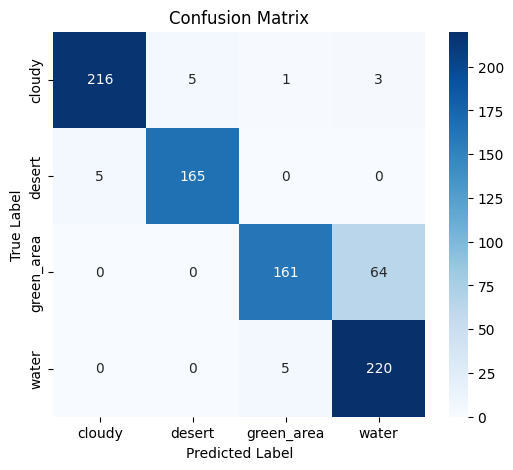

In [16]:
class_names = ["cloudy", "desert", "green_area", "water"]

cnn_acc, cnn_precision, cnn_recall, cnn_f1, cnn_cm = evaluate_model(
    model,
    test_loader,
    device,
    class_names,
)

old_cnn_acc = cnn_acc
old_cnn_precision = cnn_precision
old_cnn_recall = cnn_recall
old_cnn_f1 = cnn_f1
old_cnn_cm = cnn_cm


### Improved CNN with batch normalization

In [ ]:
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(ImprovedCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(128 * 28 * 28, 256)
        self.dropout = nn.Dropout(0.4)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x


### Initialize loss, optimizer, and train improved CNN

In [25]:
improved_model = ImprovedCNN(num_classes=4).to(device)

criterion_improved = nn.CrossEntropyLoss()

optimizer_improved = torch.optim.Adam(
    improved_model.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

print("Improved CNN initialized on:", device)

improved_train_losses, improved_val_losses, improved_train_accuracies, improved_val_accuracies = train_model(
    model=improved_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_improved,
    optimizer=optimizer_improved,
    device=device,
    epochs=10
)

Epoch [1/10] Train Loss: 1.2352, Train Acc: 0.7696 | Val Loss: 0.2509, Val Acc: 0.8864
Epoch [2/10] Train Loss: 0.3854, Train Acc: 0.8592 | Val Loss: 0.5125, Val Acc: 0.8189
Epoch [3/10] Train Loss: 0.3580, Train Acc: 0.8645 | Val Loss: 0.2269, Val Acc: 0.9136
Epoch [4/10] Train Loss: 0.3227, Train Acc: 0.8673 | Val Loss: 0.2264, Val Acc: 0.8864
Epoch [5/10] Train Loss: 0.3428, Train Acc: 0.8625 | Val Loss: 0.2927, Val Acc: 0.8651
Epoch [6/10] Train Loss: 0.3041, Train Acc: 0.8810 | Val Loss: 0.1886, Val Acc: 0.9314
Epoch [7/10] Train Loss: 0.3443, Train Acc: 0.8632 | Val Loss: 0.2677, Val Acc: 0.8746
Epoch [8/10] Train Loss: 0.3304, Train Acc: 0.8741 | Val Loss: 0.2340, Val Acc: 0.8970
Epoch [9/10] Train Loss: 0.4054, Train Acc: 0.8371 | Val Loss: 0.2319, Val Acc: 0.8888
Epoch [10/10] Train Loss: 0.2982, Train Acc: 0.8881 | Val Loss: 0.1904, Val Acc: 0.9325


### Evaluate improved CNN and compare to baseline

In [28]:
new_cnn_acc, new_cnn_precision, new_cnn_recall, new_cnn_f1, new_cnn_cm = evaluate_model(
    improved_model,
    test_loader,
    device,
    class_names,
)

cnn_comparison_df = pd.DataFrame(
    {
        "Model": ["Original CNN", "Improved CNN"],
        "Accuracy": [old_cnn_acc, new_cnn_acc],
        "Precision": [old_cnn_precision, new_cnn_precision],
        "Recall": [old_cnn_recall, new_cnn_recall],
        "F1-Score": [old_cnn_f1, new_cnn_f1],
    }
)

cnn_comparison_df


,Model,Accuracy,Precision,Recall,F1-Score
0,Original CNN,0.901775,0.919647,0.905980,0.905000
1,Improved CNN,0.936095,0.938619,0.938922,0.938682


### Learning curves — baseline custom CNN

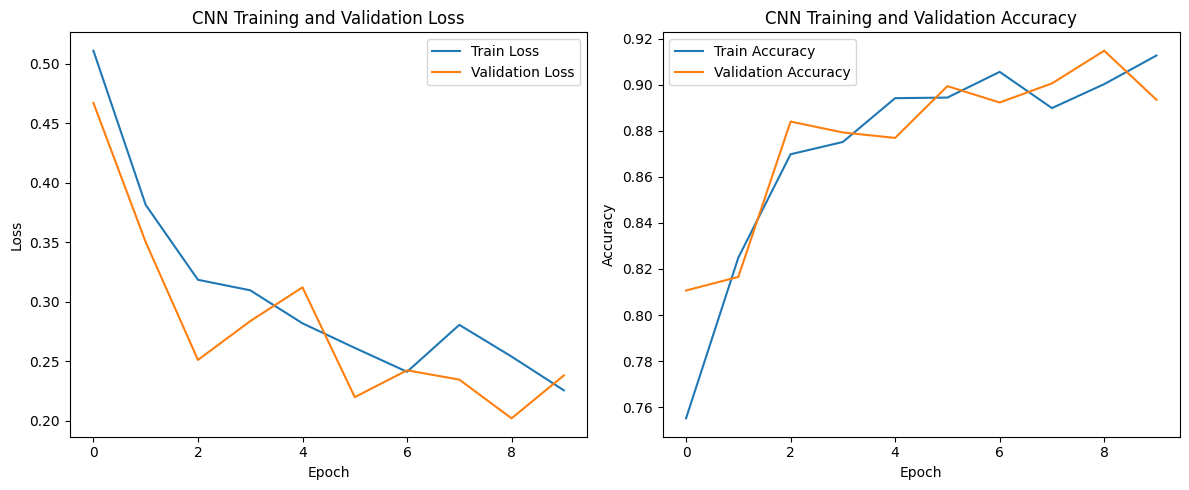

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### Sample predictions — baseline custom CNN

In [ ]:
show_predictions(model, test_loader, device, class_names)


## 6. Transfer learning — ResNet50 (frozen backbone)

Replace the classifier head and train only the final linear layer.

In [ ]:
from torchvision import models
import torch.nn as nn

# load ResNet50 model
resnet_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# freeze all layers to preserve ResNet's pretrained weights
for param in resnet_model.parameters():
    param.requires_grad = False

# adjust resnet for 4 output classes
num_features = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_features, 4)

resnet_model = resnet_model.to(device)

# loss function
criterion_resnet = nn.CrossEntropyLoss()
# optimizer only updates the final layer
optimizer_resnet = torch.optim.Adam(resnet_model.fc.parameters(), lr=0.001)

print("ResNet50 initialized.")

ResNet50 initialized.


### Train ResNet50

In [ ]:
resnet_train_losses, resnet_val_losses, resnet_train_accuracies, resnet_val_accuracies = train_model(
    model=resnet_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_resnet,
    optimizer=optimizer_resnet,
    device=device,
    epochs=10
)

Epoch [1/10] Train Loss: 0.3854, Train Acc: 0.9297 | Val Loss: 0.2319, Val Acc: 0.9538
Epoch [2/10] Train Loss: 0.1207, Train Acc: 0.9761 | Val Loss: 0.1364, Val Acc: 0.9669
Epoch [3/10] Train Loss: 0.0850, Train Acc: 0.9810 | Val Loss: 0.0901, Val Acc: 0.9846
Epoch [4/10] Train Loss: 0.0624, Train Acc: 0.9848 | Val Loss: 0.0648, Val Acc: 0.9929
Epoch [5/10] Train Loss: 0.0575, Train Acc: 0.9853 | Val Loss: 0.0525, Val Acc: 0.9917
Epoch [6/10] Train Loss: 0.0505, Train Acc: 0.9860 | Val Loss: 0.0508, Val Acc: 0.9929
Epoch [7/10] Train Loss: 0.0480, Train Acc: 0.9891 | Val Loss: 0.0438, Val Acc: 0.9917
Epoch [8/10] Train Loss: 0.0476, Train Acc: 0.9883 | Val Loss: 0.0367, Val Acc: 0.9917
Epoch [9/10] Train Loss: 0.0466, Train Acc: 0.9855 | Val Loss: 0.0364, Val Acc: 0.9929
Epoch [10/10] Train Loss: 0.0343, Train Acc: 0.9914 | Val Loss: 0.0375, Val Acc: 0.9893


### Evaluate ResNet50

Test Accuracy:  0.9941
Test Precision: 0.9945
Test Recall:    0.9944
Test F1-Score:  0.9944

Classification Report:
              precision    recall  f1-score   support

      cloudy       1.00      1.00      1.00       225
      desert       1.00      1.00      1.00       170
  green_area       0.99      1.00      0.99       225
       water       0.99      0.99      0.99       225

    accuracy                           0.99       845
   macro avg       0.99      0.99      0.99       845
weighted avg       0.99      0.99      0.99       845



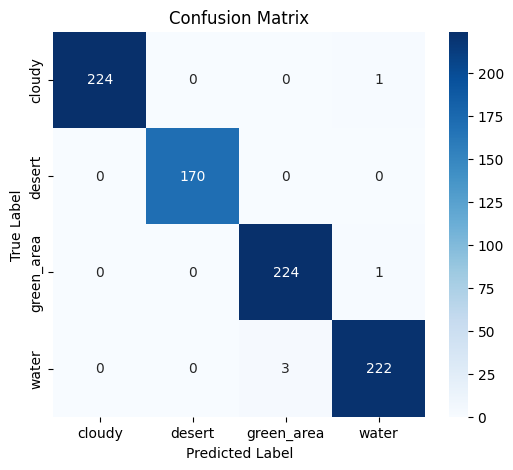

In [ ]:
resnet_acc, resnet_precision, resnet_recall, resnet_f1, resnet_cm = evaluate_model(
    resnet_model,
    test_loader,
    device,
    class_names
)

### Learning curves — ResNet50

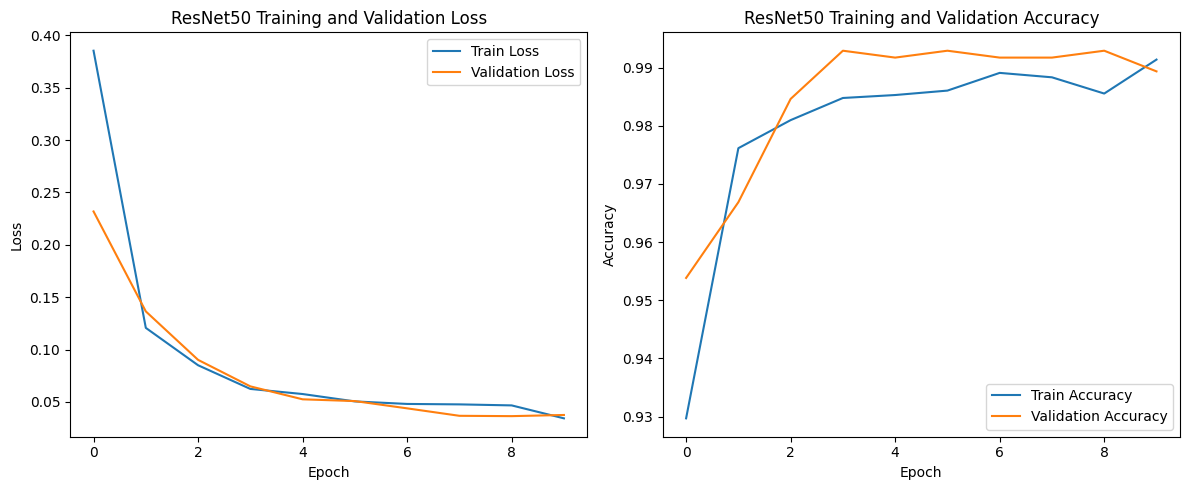

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(resnet_train_losses, label='Train Loss')
plt.plot(resnet_val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ResNet50 Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(resnet_train_accuracies, label='Train Accuracy')
plt.plot(resnet_val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('ResNet50 Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### Sample predictions — ResNet50

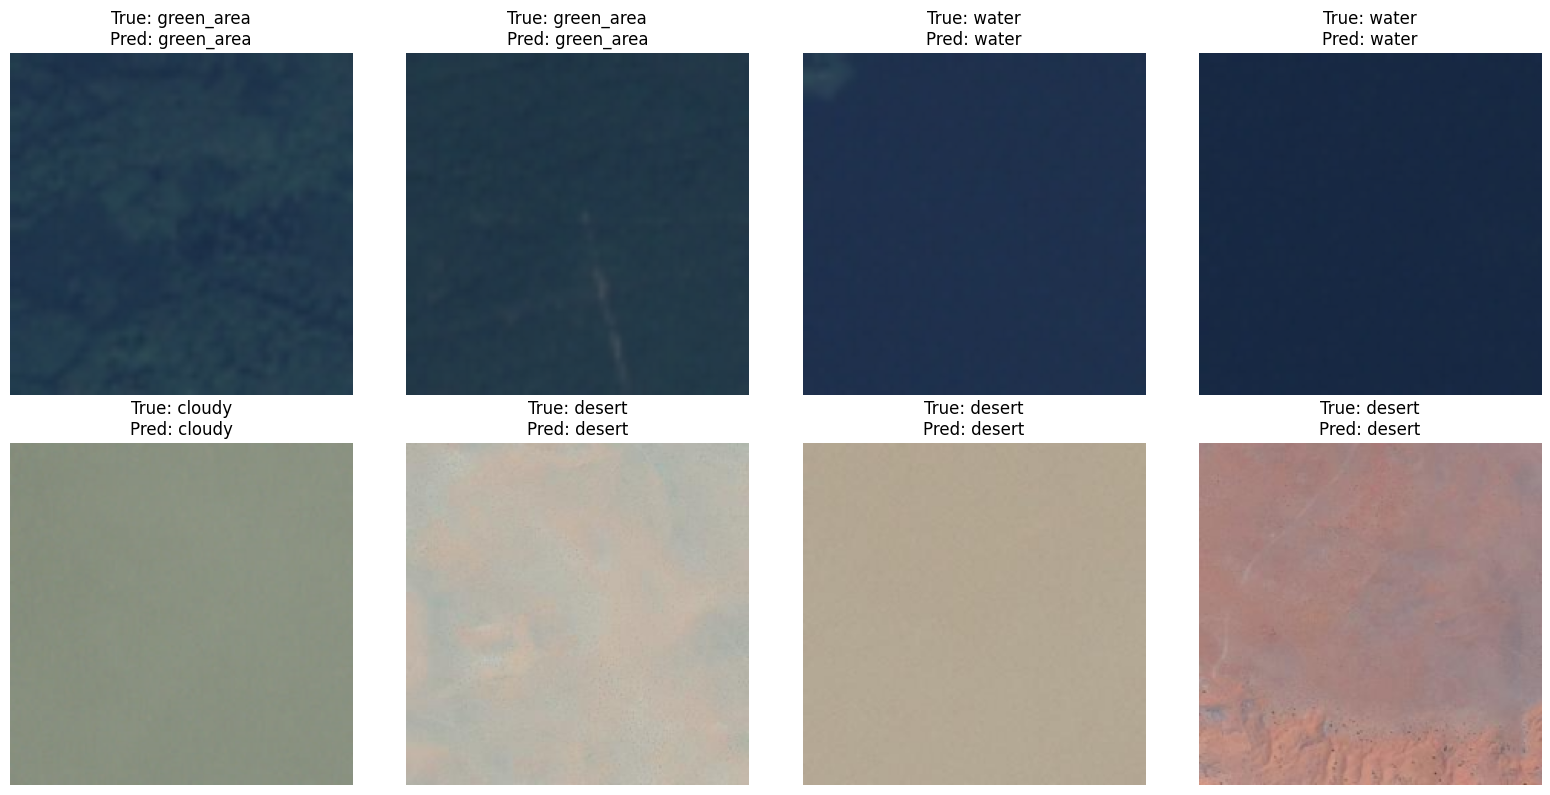

In [ ]:
show_predictions(resnet_model, test_loader, device, class_names)

## 7. Metrics comparison — custom CNN vs ResNet50

Table uses the **original** custom CNN (not the improved variant) to match the earlier comparison.

In [ ]:
results_df = pd.DataFrame(
    {
        "Model": ["Custom CNN", "ResNet50"],
        "Accuracy": [cnn_acc, resnet_acc],
        "Precision": [cnn_precision, resnet_precision],
        "Recall": [cnn_recall, resnet_recall],
        "F1-Score": [cnn_f1, resnet_f1],
    }
)

results_df


,Model,Accuracy,Precision,Recall,F1-Score
0,Custom CNN,0.889941,0.900221,0.895948,0.894696
1,ResNet50,0.994083,0.994464,0.994444,0.994447


### Bar chart — CNN vs ResNet50

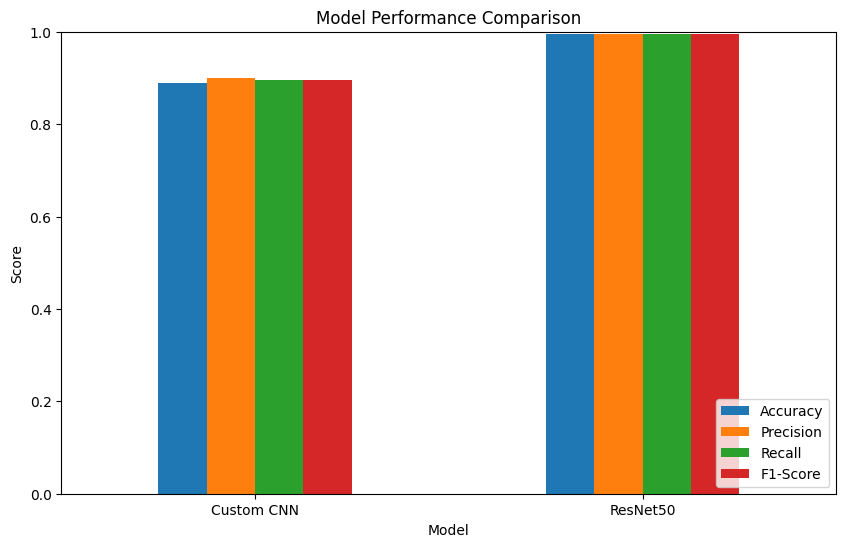

In [ ]:
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.show()

## 8. Fine-tuned ResNet — layer 4 unfrozen + 5-fold CV

Each fold trains a fresh ResNet; the **last** fold’s weights are kept as `ft_resnet_model` for the test evaluation in the next cell.


Fold 1
Epoch [1/10] Train Loss: 0.3577, Train Acc: 0.9312 | Val Loss: 0.0129, Val Acc: 1.0000
Epoch [2/10] Train Loss: 0.0425, Train Acc: 0.9883 | Val Loss: 0.0073, Val Acc: 1.0000
Epoch [3/10] Train Loss: 0.0270, Train Acc: 0.9937 | Val Loss: 0.0069, Val Acc: 0.9987
Epoch [4/10] Train Loss: 0.0196, Train Acc: 0.9940 | Val Loss: 0.0048, Val Acc: 1.0000
Epoch [5/10] Train Loss: 0.0213, Train Acc: 0.9943 | Val Loss: 0.0030, Val Acc: 1.0000
Epoch [6/10] Train Loss: 0.0113, Train Acc: 0.9968 | Val Loss: 0.0024, Val Acc: 1.0000
Epoch [7/10] Train Loss: 0.0152, Train Acc: 0.9962 | Val Loss: 0.0031, Val Acc: 0.9987
Epoch [8/10] Train Loss: 0.0062, Train Acc: 0.9994 | Val Loss: 0.0037, Val Acc: 0.9987
Epoch [9/10] Train Loss: 0.0040, Train Acc: 0.9994 | Val Loss: 0.0007, Val Acc: 1.0000
Epoch [10/10] Train Loss: 0.0080, Train Acc: 0.9981 | Val Loss: 0.0015, Val Acc: 1.0000
Test Accuracy:  0.9987
Test Precision: 0.9988
Test Recall:    0.9987
Test F1-Score:  0.9987

Classification Report:
     

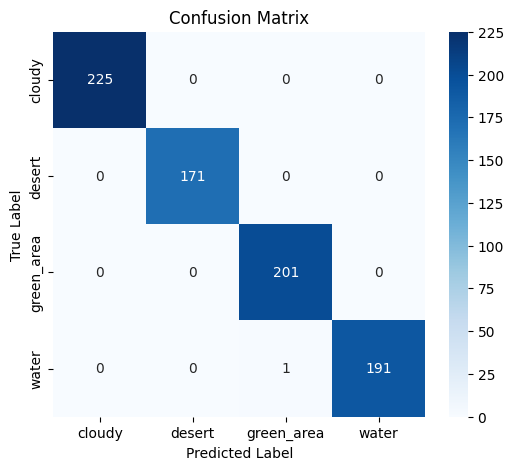


Fold 2
Epoch [1/10] Train Loss: 0.3492, Train Acc: 0.9324 | Val Loss: 0.0191, Val Acc: 0.9975
Epoch [2/10] Train Loss: 0.0329, Train Acc: 0.9921 | Val Loss: 0.0131, Val Acc: 0.9949
Epoch [3/10] Train Loss: 0.0269, Train Acc: 0.9933 | Val Loss: 0.0078, Val Acc: 0.9962
Epoch [4/10] Train Loss: 0.0160, Train Acc: 0.9965 | Val Loss: 0.0040, Val Acc: 1.0000
Epoch [5/10] Train Loss: 0.0157, Train Acc: 0.9962 | Val Loss: 0.0065, Val Acc: 0.9987
Epoch [6/10] Train Loss: 0.0109, Train Acc: 0.9965 | Val Loss: 0.0036, Val Acc: 1.0000
Epoch [7/10] Train Loss: 0.0114, Train Acc: 0.9975 | Val Loss: 0.0025, Val Acc: 1.0000
Epoch [8/10] Train Loss: 0.0125, Train Acc: 0.9962 | Val Loss: 0.0069, Val Acc: 1.0000
Epoch [9/10] Train Loss: 0.0072, Train Acc: 0.9990 | Val Loss: 0.0028, Val Acc: 0.9987
Epoch [10/10] Train Loss: 0.0031, Train Acc: 0.9997 | Val Loss: 0.0008, Val Acc: 1.0000
Test Accuracy:  0.9987
Test Precision: 0.9988
Test Recall:    0.9989
Test F1-Score:  0.9988

Classification Report:
     

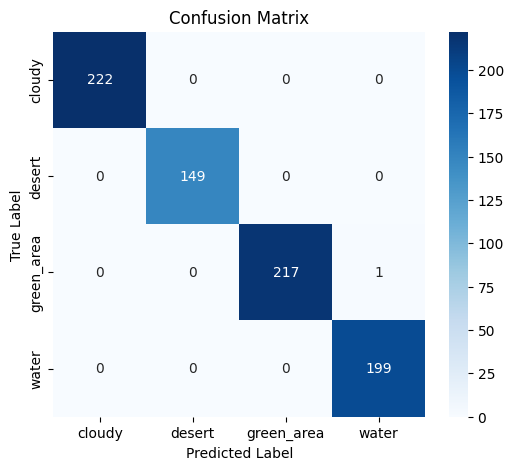


Fold 3
Epoch [1/10] Train Loss: 0.3336, Train Acc: 0.9397 | Val Loss: 0.0235, Val Acc: 0.9937
Epoch [2/10] Train Loss: 0.0394, Train Acc: 0.9879 | Val Loss: 0.0128, Val Acc: 0.9962
Epoch [3/10] Train Loss: 0.0277, Train Acc: 0.9933 | Val Loss: 0.0080, Val Acc: 0.9975
Epoch [4/10] Train Loss: 0.0163, Train Acc: 0.9965 | Val Loss: 0.0084, Val Acc: 0.9987
Epoch [5/10] Train Loss: 0.0179, Train Acc: 0.9952 | Val Loss: 0.0045, Val Acc: 1.0000
Epoch [6/10] Train Loss: 0.0246, Train Acc: 0.9937 | Val Loss: 0.0072, Val Acc: 0.9987
Epoch [7/10] Train Loss: 0.0118, Train Acc: 0.9975 | Val Loss: 0.0103, Val Acc: 0.9962
Epoch [8/10] Train Loss: 0.0072, Train Acc: 0.9984 | Val Loss: 0.0183, Val Acc: 0.9975
Epoch [9/10] Train Loss: 0.0122, Train Acc: 0.9968 | Val Loss: 0.0105, Val Acc: 0.9962
Epoch [10/10] Train Loss: 0.0063, Train Acc: 0.9990 | Val Loss: 0.0036, Val Acc: 0.9987
Test Accuracy:  0.9987
Test Precision: 0.9988
Test Recall:    0.9989
Test F1-Score:  0.9989

Classification Report:
     

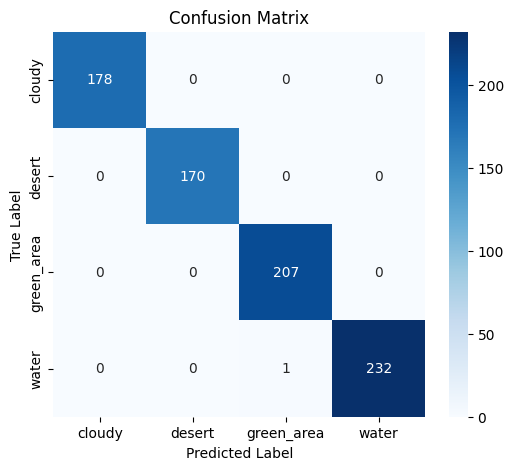


Fold 4
Epoch [1/10] Train Loss: 0.3320, Train Acc: 0.9401 | Val Loss: 0.0210, Val Acc: 0.9962
Epoch [2/10] Train Loss: 0.0444, Train Acc: 0.9889 | Val Loss: 0.0218, Val Acc: 0.9937
Epoch [3/10] Train Loss: 0.0313, Train Acc: 0.9933 | Val Loss: 0.0156, Val Acc: 0.9924
Epoch [4/10] Train Loss: 0.0191, Train Acc: 0.9940 | Val Loss: 0.0104, Val Acc: 0.9975
Epoch [5/10] Train Loss: 0.0154, Train Acc: 0.9968 | Val Loss: 0.0193, Val Acc: 0.9937
Epoch [6/10] Train Loss: 0.0110, Train Acc: 0.9971 | Val Loss: 0.0088, Val Acc: 0.9962
Epoch [7/10] Train Loss: 0.0169, Train Acc: 0.9956 | Val Loss: 0.0086, Val Acc: 0.9962
Epoch [8/10] Train Loss: 0.0082, Train Acc: 0.9984 | Val Loss: 0.0111, Val Acc: 0.9949
Epoch [9/10] Train Loss: 0.0052, Train Acc: 0.9987 | Val Loss: 0.0091, Val Acc: 0.9987
Epoch [10/10] Train Loss: 0.0095, Train Acc: 0.9975 | Val Loss: 0.0087, Val Acc: 0.9975
Test Accuracy:  0.9962
Test Precision: 0.9965
Test Recall:    0.9964
Test F1-Score:  0.9964

Classification Report:
     

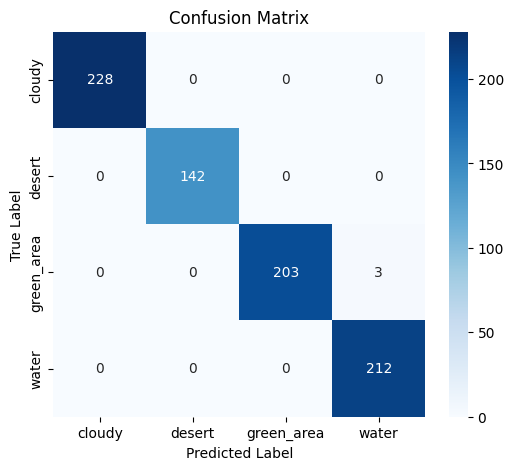


Fold 5
Epoch [1/10] Train Loss: 0.3309, Train Acc: 0.9467 | Val Loss: 0.0246, Val Acc: 0.9949
Epoch [2/10] Train Loss: 0.0465, Train Acc: 0.9876 | Val Loss: 0.0142, Val Acc: 0.9975
Epoch [3/10] Train Loss: 0.0261, Train Acc: 0.9940 | Val Loss: 0.0104, Val Acc: 0.9949
Epoch [4/10] Train Loss: 0.0158, Train Acc: 0.9959 | Val Loss: 0.0063, Val Acc: 0.9975
Epoch [5/10] Train Loss: 0.0082, Train Acc: 0.9978 | Val Loss: 0.0065, Val Acc: 0.9962
Epoch [6/10] Train Loss: 0.0086, Train Acc: 0.9984 | Val Loss: 0.0018, Val Acc: 1.0000
Epoch [7/10] Train Loss: 0.0149, Train Acc: 0.9962 | Val Loss: 0.0052, Val Acc: 0.9987
Epoch [8/10] Train Loss: 0.0087, Train Acc: 0.9968 | Val Loss: 0.0054, Val Acc: 0.9987
Epoch [9/10] Train Loss: 0.0091, Train Acc: 0.9978 | Val Loss: 0.0057, Val Acc: 0.9975
Epoch [10/10] Train Loss: 0.0062, Train Acc: 0.9987 | Val Loss: 0.0055, Val Acc: 0.9975
Test Accuracy:  0.9987
Test Precision: 0.9988
Test Recall:    0.9989
Test F1-Score:  0.9988

Classification Report:
     

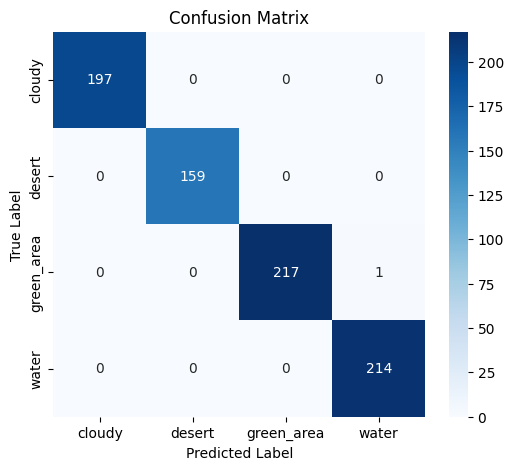


Cross-Validation Results
Mean Accuracy: 0.9982236719358181
Std Dev: 0.0010153894584844386


In [ ]:
from sklearn.model_selection import KFold
from torchvision import models

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(train_dataset)):
    print()
    print(f"Fold {fold+1}")

    ft_resnet_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

    for param in ft_resnet_model.parameters():
        param.requires_grad = False

    for param in ft_resnet_model.layer4.parameters():
        param.requires_grad = True

    ft_resnet_model.fc = nn.Linear(ft_resnet_model.fc.in_features, 4)
    ft_resnet_model = ft_resnet_model.to(device)

    optimizer = torch.optim.Adam(ft_resnet_model.parameters(), lr=1e-4)

    train_subset = torch.utils.data.Subset(train_dataset, train_idx)
    val_subset = torch.utils.data.Subset(train_dataset, val_idx)

    train_loader_cv = torch.utils.data.DataLoader(
        train_subset, batch_size=32, shuffle=True
    )
    val_loader_cv = torch.utils.data.DataLoader(
        val_subset, batch_size=32, shuffle=False
    )

    ft_train_losses, ft_val_losses, ft_train_acc, ft_val_acc = train_model(
        model=ft_resnet_model,
        train_loader=train_loader_cv,
        val_loader=val_loader_cv,
        criterion=criterion_resnet,
        optimizer=optimizer,
        device=device,
        epochs=10,
    )

    acc = evaluate_model(ft_resnet_model, val_loader_cv, device, class_names)[0]
    cv_scores.append(acc)

print()
print("Cross-Validation Results")
print("Mean Accuracy:", np.mean(cv_scores))


## 9. Evaluate fine-tuned ResNet on the held-out test set

In [ ]:
ft_acc, ft_precision, ft_recall, ft_f1, ft_cm = evaluate_model(
    ft_resnet_model,
    test_loader,
    device,
    class_names,
)


## 10. Compare all three approaches

In [ ]:
results_df = pd.DataFrame(
    {
        "Model": ["Custom CNN", "ResNet50", "Fine-Tuned ResNet"],
        "Accuracy": [cnn_acc, resnet_acc, ft_acc],
        "Precision": [cnn_precision, resnet_precision, ft_precision],
        "Recall": [cnn_recall, resnet_recall, ft_recall],
        "F1-Score": [cnn_f1, resnet_f1, ft_f1],
        "Train Loss": [
            train_losses[-1],
            resnet_train_losses[-1],
            ft_train_losses[-1],
        ],
        "Val Loss": [val_losses[-1], resnet_val_losses[-1], ft_val_losses[-1]],
    }
)

results_df


,Model,Accuracy,Precision,Recall,F1-Score,Train Loss,Val Loss
0,Custom CNN,0.889941,0.900221,0.895948,0.894696,0.225666,0.238226
1,ResNet50,0.994083,0.994464,0.994444,0.994447,0.034286,0.037502
2,Fine-Tuned ResNet,0.996450,0.996672,0.996667,0.996667,0.006188,0.005459
